# Análise de Similaridade e Visualização de Letras de Músicas Brasileiras

Este notebook parte do dataset `songs.csv` e realiza:

1. limpeza textual avançada  
2. tokenização  
3. stemming  
4. lemmatização  
5. remoção de stopwords customizadas  
6. vetorização com Bag of Words e TF-IDF  
7. busca por similaridade por tema e por música  
8. visualizações com heatmap e PCA  

> Observação: este notebook assume que o arquivo `songs.csv` já foi gerado na etapa de coleta.


## 1. Instalação e importação de bibliotecas

In [1]:
!pip -q install spacy nltk scikit-learn seaborn pandas matplotlib
!python -m spacy download pt_core_news_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 73.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import re
import string
import unicodedata
import warnings

import numpy as np
import pandas as pd
import nltk
import spacy
import seaborn as sns
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

## 2. Downloads do NLTK e carregamento do dataset

In [3]:
for resource, path in [
    ("punkt", "tokenizers/punkt"),
    ("punkt_tab", "tokenizers/punkt_tab"),
    ("stopwords", "corpora/stopwords"),
    ("rslp", "stemmers/rslp"),
]:
    try:
        nltk.data.find(path)
    except LookupError:
        nltk.download(resource)

nlp = spacy.load("pt_core_news_sm")
stemmer = RSLPStemmer()

# Ajuste o caminho se necessário
df = pd.read_csv("songs.csv")

print(df.shape)
display(df.head(3))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Unzipping stemmers/rslp.zip.


(100, 10)


,genre,artist,artist_slug,artist_url,song_title,song_url,lyrics_raw,lyrics_clean,n_words,n_chars
0,mpb,Maria Bethânia,maria-bethania,https://www.letras.com.br/maria-bethania/,Iemanjá Rainha Do Mar,https://www.letras.com.br/maria-bethania/iemanja-rainha-do-mar,"Quanto nome tem a Rainha do Mar?\nQuanto nome tem a Rainha do Mar?\nDandalunda, Janaína,\nMarabô, Princesa de Aiocá,...","Quanto nome tem a Rainha do Mar?\nQuanto nome tem a Rainha do Mar?\nDandalunda, Janaína,\nMarabô, Princesa de Aiocá,...",163,852
1,mpb,Maria Bethânia,maria-bethania,https://www.letras.com.br/maria-bethania/,Samba Da Bênção,https://www.letras.com.br/maria-bethania/samba-da-bencao,É melhor ser alegre que ser triste\nAlegria é a melhor coisa que existe\nÉ assim como a luz no coração\nMas pra faze...,É melhor ser alegre que ser triste\nAlegria é a melhor coisa que existe\nÉ assim como a luz no coração\nMas pra faze...,149,712
2,mpb,Fagner,fagner,https://www.letras.com.br/fagner/,Borbulhas de Amor,https://www.letras.com.br/fagner/borbulhas-de-amor,Tenho um coração\nDividido entre a esperança e a razão\nTenho um coração\nBem melhor que não tivera\n\nEsse coração\...,Tenho um coração\nDividido entre a esperança e a razão\nTenho um coração\nBem melhor que não tivera\n\nEsse coração\...,229,1234


## 3. Limpeza textual avançada

Aqui tratamos ruídos típicos de letras de músicas, como interjeições, marcações de refrão, pontuação repetida e símbolos que escapam das stopwords padrão.

In [49]:
import unicodedata

def normalize_text(text):
    text = unicodedata.normalize("NFKD", text)
    text = "".join(c for c in text if not unicodedata.combining(c))
    return text

In [81]:
custom_noise_tokens = {
    "óh", "ô", "ôoo", "ôô", "oh", "ooo", "ooooh", "ah", "eh", "uh",
    "’", "“", "”", "''", "–", "...", "..", "....", ".....", "........",
    "-hahahah", "hahaha", "hahahaha", "ha", "lalala", "la", "aaa",
    "aaaaah", "aaaah",
    "2345meia78", "1x", "êe", "êh", "ê", "êe"
    "ê e", "youtube", "hey"
}

In [82]:
def normalize_unicode_text(text: str) -> str:
    if pd.isna(text):
        return ""

    text = str(text)
    text = text.replace("’", "'").replace("“", '"').replace("”", '"').replace("–", "-")
    text = unicodedata.normalize("NFKC", text)

    return text

In [83]:
def clean_lyrics_advanced(text):
    text = text.lower()
    text = normalize_text(text)

    # remover números
    text = re.sub(r"\d+", "", text)

    # remover tokens com números misturados
    text = re.sub(r"\b\w*\d+\w*\b", "", text)

    # remover interjeições musicais
    text = re.sub(r"\b(oh+|ah+|eh+|uh+|la+|na+)\b", "", text)

    # remover repetições de vogais
    text = re.sub(r"\b[aeiou]{2,}\b", "", text)

    # remover risadas
    text = re.sub(r"ha(ha)+", "", text)

    # remover palavras lixo conhecidas
    text = re.sub(r"\b(youtube|refr[aã]o?)\b", "", text)

    # remover pontuação
    text = re.sub(r"[^\w\s]", " ", text)

    # remover palavras muito curtas
    text = " ".join([w for w in text.split() if len(w) > 2])

    # espaços
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [84]:
df["lyrics_text_clean"] = df["lyrics_clean"].fillna("").apply(clean_lyrics_advanced)

display(df[["artist", "song_title", "lyrics_clean", "lyrics_text_clean"]].head(3))

,artist,song_title,lyrics_clean,lyrics_text_clean
0,Maria Bethânia,Iemanjá Rainha Do Mar,"Quanto nome tem a Rainha do Mar?\nQuanto nome tem a Rainha do Mar?\nDandalunda, Janaína,\nMarabô, Princesa de Aiocá,...",quanto nome tem rainha mar quanto nome tem rainha mar dandalunda janaina marabo princesa aioca inae sereia mucuna ma...
1,Maria Bethânia,Samba Da Bênção,É melhor ser alegre que ser triste\nAlegria é a melhor coisa que existe\nÉ assim como a luz no coração\nMas pra faze...,melhor ser alegre que ser triste alegria melhor coisa que existe assim como luz coracao mas pra fazer samba com bele...
2,Fagner,Borbulhas de Amor,Tenho um coração\nDividido entre a esperança e a razão\nTenho um coração\nBem melhor que não tivera\n\nEsse coração\...,tenho coracao dividido entre esperanca razao tenho coracao bem melhor que nao tivera esse coracao nao consegue conte...


## 4. Tokenização

In [85]:
def tokenize_text(text: str) -> list:
    if not isinstance(text, str) or not text.strip():
        return []

    return word_tokenize(text, language="portuguese")

In [86]:
df["lyrics_tokenized"] = df["lyrics_text_clean"].apply(tokenize_text)

display(df[["artist", "song_title", "lyrics_tokenized"]].head(3))

,artist,song_title,lyrics_tokenized
0,Maria Bethânia,Iemanjá Rainha Do Mar,"[quanto, nome, tem, rainha, mar, quanto, nome, tem, rainha, mar, dandalunda, janaina, marabo, princesa, aioca, inae,..."
1,Maria Bethânia,Samba Da Bênção,"[melhor, ser, alegre, que, ser, triste, alegria, melhor, coisa, que, existe, assim, como, luz, coracao, mas, pra, fa..."
2,Fagner,Borbulhas de Amor,"[tenho, coracao, dividido, entre, esperanca, razao, tenho, coracao, bem, melhor, que, nao, tivera, esse, coracao, na..."


## 5. Stemming

In [87]:
def stem_tokens(tokens: list) -> list:
    if not isinstance(tokens, list):
        return []

    return [stemmer.stem(token) for token in tokens if token.strip()]

In [88]:
df["lyrics_stemmed"] = df["lyrics_tokenized"].apply(stem_tokens)

display(df[["artist", "song_title", "lyrics_stemmed"]].head(3))

,artist,song_title,lyrics_stemmed
0,Maria Bethânia,Iemanjá Rainha Do Mar,"[quant, nom, tem, rainh, mar, quant, nom, tem, rainh, mar, dandalund, janain, marab, princes, aioc, ina, sere, mucun..."
1,Maria Bethânia,Samba Da Bênção,"[melhor, ser, alegr, que, ser, trist, alegr, melhor, cois, que, exist, assim, com, luz, coraca, mas, pra, faz, samb,..."
2,Fagner,Borbulhas de Amor,"[tenh, coraca, divid, entr, esperanc, raza, tenh, coraca, bem, melhor, que, nao, tiv, ess, coraca, nao, conseg, cont..."


## 6. Lemmatização

In [89]:
def lemmatize_tokens(tokens: list) -> list:
    if not isinstance(tokens, list) or len(tokens) == 0:
        return []
    doc = nlp(" ".join(tokens))

    return [token.lemma_ for token in doc if token.lemma_.strip()]

In [90]:
df["lyrics_lemmatized"] = df["lyrics_tokenized"].apply(lemmatize_tokens)

display(df[["artist", "song_title", "lyrics_lemmatized"]].head(3))

,artist,song_title,lyrics_lemmatized
0,Maria Bethânia,Iemanjá Rainha Do Mar,"[quanto, nome, ter, rainhar, mar, quanto, nome, ter, rainhar, mar, dandalunda, Janaina, marabo, princesa, aiocar, in..."
1,Maria Bethânia,Samba Da Bênção,"[bom, ser, alegre, que, ser, triste, alegria, bom, coisa, que, existir, assim, como, luz, coracao, mas, pra, fazer, ..."
2,Fagner,Borbulhas de Amor,"[ter, coracao, dividir, entre, esperanca, razao, ter, coracao, bem, bom, que, nao, tivera, esse, coracao, nao, conse..."


## 7. Stopwords customizadas e limpeza final dos tokens

In [91]:
stop_words = set(stopwords.words("portuguese"))

custom_stopwords = {
    "óh", "ô", "ôoo", "ôô", "oh", "ooo", "ooooh",
    "’", "“", "”", "''", "–",
    "..", "...", "....", ".....", "........",
    "-hahahah", "hahaha", "hahahaha", "ha",
    "refr", "refrao", "refrão",
    "lalala", "la", "aaa", "i", "aaaaah", "aaaah",
    "2345meia78", "1x", "êe", "êh", "ê", "êe"
    "ê e", "youtube", "hey"
}

stop_words.update(custom_stopwords)

# pontuação e símbolos comuns em letras
extra_punct = set(string.punctuation) | {"''", "``", "--", "—", "–"}

In [92]:
def preprocess_tokens(tokens: list) -> list:
    if not isinstance(tokens, list):
        return []

    cleaned = []
    for token in tokens:
        tok = normalize_unicode_text(token).lower().strip()
        tok = re.sub(r"[^\w\s]", "", tok)

        if not tok:
            continue
        if tok in stop_words:
            continue
        if tok in extra_punct:
            continue
        if re.fullmatch(r"_+", tok):
            continue
        if re.fullmatch(r"(ha)+h?", tok):
            continue
        if re.fullmatch(r"(oh+|ô+|ó+|ah+|eh+|uh+)", tok):
            continue

        cleaned.append(tok)

    return cleaned

In [93]:
df["lyrics_cleaned_final"] = df["lyrics_lemmatized"].apply(preprocess_tokens)

display(df[["artist", "song_title", "lyrics_cleaned_final"]].head(3))

,artist,song_title,lyrics_cleaned_final
0,Maria Bethânia,Iemanjá Rainha Do Mar,"[quanto, nome, ter, rainhar, mar, quanto, nome, ter, rainhar, mar, dandalunda, janaina, marabo, princesa, aiocar, in..."
1,Maria Bethânia,Samba Da Bênção,"[bom, alegre, triste, alegria, bom, coisa, existir, assim, luz, coracao, pra, fazer, samba, beleza, preciso, bocado,..."
2,Fagner,Borbulhas de Amor,"[ter, coracao, dividir, esperanca, razao, ter, coracao, bem, bom, nao, coracao, nao, conseguir, conter, ouvir, voz, ..."


In [94]:
# Conferência dos tokens mais frequentes após a limpeza
all_tokens = [tok for tokens in df["lyrics_cleaned_final"] for tok in tokens]
freq = pd.Series(all_tokens).value_counts().head(40)
display(freq)

,count
nao,457
pra,260
voce,256
ir,252
ter,195
saber,137
querer,131
amor,126
fazer,122
vir,96


## 8. Preparação do corpus

In [95]:
df["corpus_clean"] = df["lyrics_cleaned_final"].apply(lambda tokens: " ".join(tokens))
df["doc_label"] = df["artist"] + " - " + df["song_title"]

display(df[["genre", "artist", "song_title", "corpus_clean"]].head(3))

,genre,artist,song_title,corpus_clean
0,mpb,Maria Bethânia,Iemanjá Rainha Do Mar,quanto nome ter rainhar mar quanto nome ter rainhar mar dandalunda janaina marabo princesa aiocar inae serear mucuna...
1,mpb,Maria Bethânia,Samba Da Bênção,bom alegre triste alegria bom coisa existir assim luz coracao pra fazer samba beleza preciso bocado tristeza preciso...
2,mpb,Fagner,Borbulhas de Amor,ter coracao dividir esperanca razao ter coracao bem bom nao coracao nao conseguir conter ouvir voz pobre coracao sem...


## 9. Vetorização com Bag of Words

In [96]:
bow_vec = CountVectorizer(
    lowercase=True,
    token_pattern=r"(?u)\b\w+\b",
    min_df=1
)

X_bow = bow_vec.fit_transform(df["corpus_clean"])
df_bow = pd.DataFrame(X_bow.toarray(), columns=bow_vec.get_feature_names_out())

In [97]:
print("Formato BoW:", X_bow.shape)
display(df_bow.head())

Formato BoW: (100, 3458)


,a,abaixar,abaixo,abalar,abandonar,abencoar,abencoe,aberracao,abertas,aberto,...,you,your,yours,zaac,ziguezaguiei,zoio,zona,zoo,zuar,zumira
0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 10. Vetorização com TF-IDF

In [98]:
tfidf_vec = TfidfVectorizer(
    lowercase=True,
    token_pattern=r"(?u)\b\w+\b",
    min_df=1
)

X_tfidf = tfidf_vec.fit_transform(df["corpus_clean"])
df_tfidf = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vec.get_feature_names_out())

print("Formato TF-IDF:", X_tfidf.shape)
display(df_tfidf.iloc[:5, :10].round(3))

Formato TF-IDF: (100, 3458)


,a,abaixar,abaixo,abalar,abandonar,abencoar,abencoe,aberracao,abertas,aberto
0,0.0,0.0,0.0,0.0,0.0,0.086,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0


## 11. Busca por similaridade

### 11.1 Similaridade por tema
A consulta é vetorizada e comparada com todas as músicas do corpus.

In [99]:
def search_by_theme(query: str, vectorizer, X_corpus, df_docs: pd.DataFrame, top_n: int = 5) -> pd.DataFrame:
    query_clean = clean_lyrics_advanced(query)
    query_vec = vectorizer.transform([query_clean])
    sim_scores = cosine_similarity(query_vec, X_corpus).ravel()
    rank = np.argsort(sim_scores)[::-1][:top_n]

    results = df_docs.loc[rank, ["genre", "artist", "song_title"]].copy()
    results["similarity"] = sim_scores[rank]
    results["query"] = query
    return results.reset_index(drop=True)

query = "saudade amor tristeza esperança"
theme_results = search_by_theme(query, tfidf_vec, X_tfidf, df, top_n=5)
display(theme_results)

,genre,artist,song_title,similarity,query
0,mpb,Maria Bethânia,Samba Da Bênção,0.262870,saudade amor tristeza esperança
1,sertanejo,Leonardo,E Não Vou Mais Deixar Você Tão Só,0.196021,saudade amor tristeza esperança
2,mpb,Elis Regina,Preciso Aprender a Ser Só,0.146585,saudade amor tristeza esperança
3,mpb,Alcione,Trocando Em Miúdos,0.126686,saudade amor tristeza esperança
4,mpb,Fagner,Oração de São Francisco,0.113314,saudade amor tristeza esperança


### 11.2 Similaridade música com música

In [100]:
song_similarity_matrix = cosine_similarity(X_tfidf)

In [101]:
def get_similar_songs(df_docs: pd.DataFrame, similarity_matrix, song_index: int, top_n: int = 5) -> pd.DataFrame:
    scores = list(enumerate(similarity_matrix[song_index]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    # ignora a própria música
    top = scores[1: top_n + 1]

    results = []
    for idx, score in top:
        results.append({
            "genre": df_docs.iloc[idx]["genre"],
            "artist": df_docs.iloc[idx]["artist"],
            "song_title": df_docs.iloc[idx]["song_title"],
            "similarity": score
        })

    return pd.DataFrame(results)

In [102]:
song_index = 0
print("Música consultada:")
display(df.loc[[song_index], ["genre", "artist", "song_title"]])

Música consultada:


,genre,artist,song_title
0,mpb,Maria Bethânia,Iemanjá Rainha Do Mar


In [103]:
print("Músicas similares:")
similar_songs = get_similar_songs(df, song_similarity_matrix, song_index=song_index, top_n=5)
display(similar_songs)

Músicas similares:


,genre,artist,song_title,similarity
0,rock,Gal Costa,Canta Brasil,0.216505
1,rap,Racionais MC’s,Jesus Chorou,0.136012
2,rap,L7NNON,"Berenice (part. BIN, Dfideliz, Califfa)",0.117182
3,rap,L7NNON,Silvana,0.105405
4,rap,Criolo,Casa de Mãe,0.101080


## 12. Visualizações

Como 100 documentos tornam um heatmap completo pouco legível, fazemos recortes por gênero ou por amostra.

### 12.1 Heatmap de similaridade (recorte por gênero)

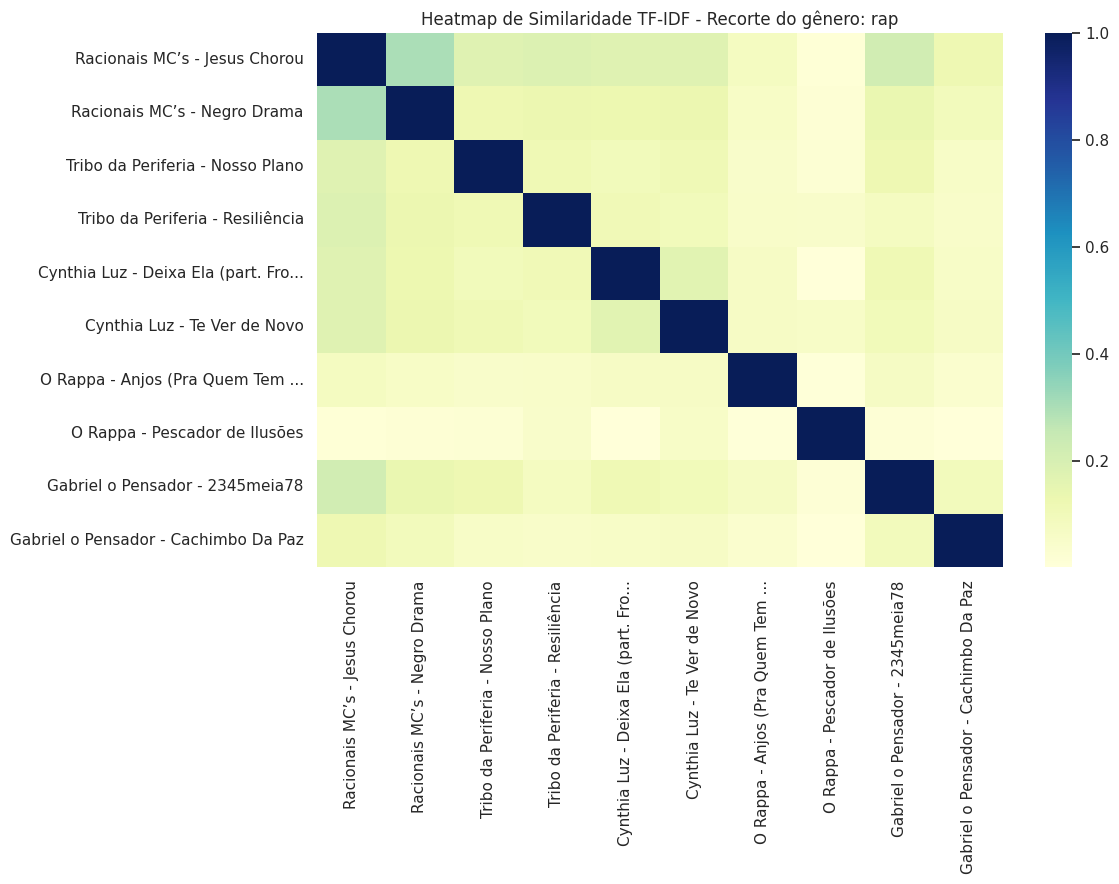

In [104]:
selected_genre = "rap"
subset_df = df[df["genre"] == selected_genre].head(10).copy()
subset_idx = subset_df.index.tolist()

subset_similarity = cosine_similarity(X_tfidf[subset_idx], X_tfidf[subset_idx])

heatmap_labels = [
    f"{row.artist} - {row.song_title[:20]}..." if len(row.song_title) > 20 else f"{row.artist} - {row.song_title}"
    for _, row in subset_df.iterrows()
]

plt.figure(figsize=(12, 9))
sns.heatmap(
    subset_similarity,
    xticklabels=heatmap_labels,
    yticklabels=heatmap_labels,
    cmap="YlGnBu",
    annot=False
)

plt.title(f"Heatmap de Similaridade TF-IDF - Recorte do gênero: {selected_genre}")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 12.2 PCA dos documentos

Com 100 documentos, o PCA continua viável. Em vez de anotar todos os pontos, usamos cor por gênero.

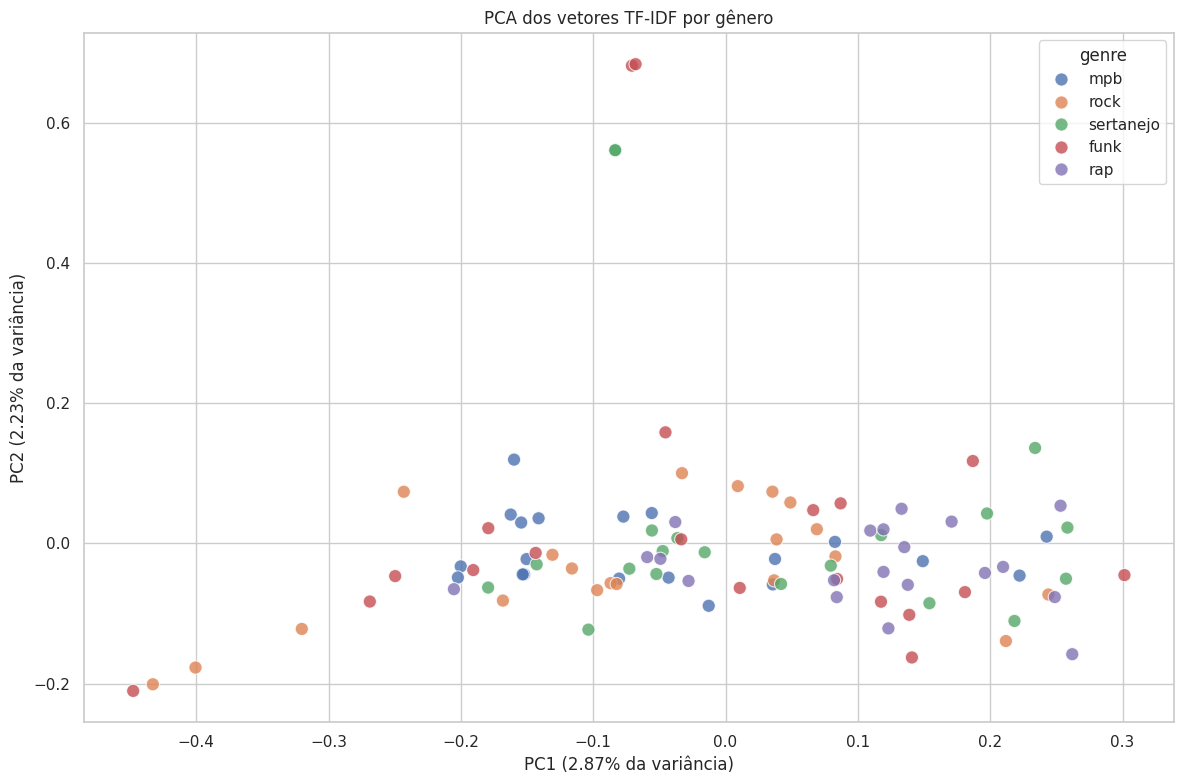

Variância explicada total pelas duas componentes: 0.0509


In [105]:
pca = PCA(n_components=2, random_state=42)
X_tfidf_dense = X_tfidf.toarray()
X_pca = pca.fit_transform(X_tfidf_dense)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "genre": df["genre"],
    "artist": df["artist"],
    "song_title": df["song_title"]
})

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="genre",
    s=90,
    alpha=0.8
)

plt.title("PCA dos vetores TF-IDF por gênero")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} da variância)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} da variância)")
plt.tight_layout()
plt.show()

print("Variância explicada total pelas duas componentes:", round(pca.explained_variance_ratio_.sum(), 4))

### 12.3 PCA com recorte anotado

Se quiser visualizar um conjunto menor com rótulos, use um recorte de até 15 músicas.

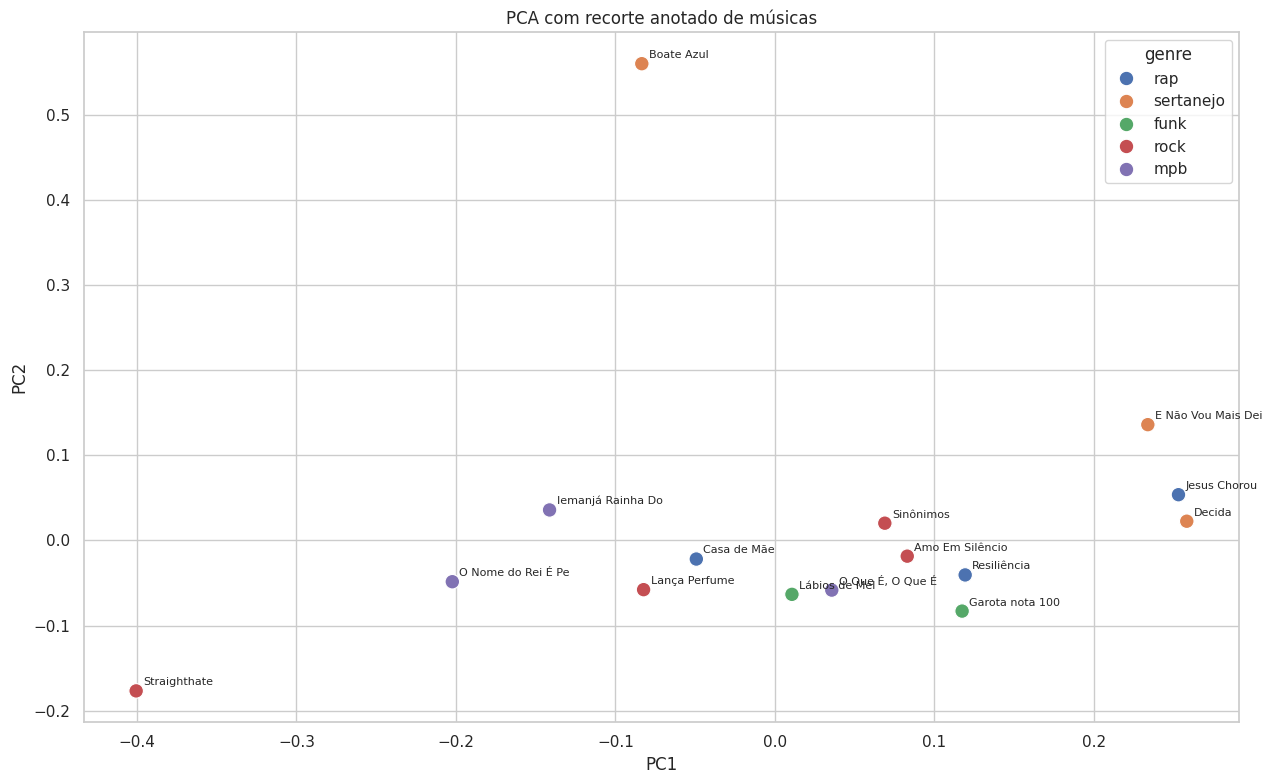

In [106]:
subset_pca_df = pca_df.sample(15, random_state=42).copy()

plt.figure(figsize=(13, 8))
sns.scatterplot(
    data=subset_pca_df,
    x="PC1",
    y="PC2",
    hue="genre",
    s=110
)

for _, row in subset_pca_df.iterrows():
    plt.annotate(
        row["song_title"][:18],
        (row["PC1"], row["PC2"]),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=8
    )

plt.title("PCA com recorte anotado de músicas")
plt.tight_layout()
plt.show()

## 13. Tabelas auxiliares para interpretação

In [107]:
# Termos mais importantes por TF-IDF médio em cada gênero
tfidf_feature_names = np.array(tfidf_vec.get_feature_names_out())

genre_top_terms = []

for genre_name in sorted(df["genre"].unique()):
    genre_idx = df[df["genre"] == genre_name].index
    mean_tfidf = np.asarray(X_tfidf[genre_idx].mean(axis=0)).ravel()
    top_idx = mean_tfidf.argsort()[::-1][:10]

    for rank, term_idx in enumerate(top_idx, start=1):
        genre_top_terms.append({
            "genre": genre_name,
            "rank": rank,
            "term": tfidf_feature_names[term_idx],
            "mean_tfidf": mean_tfidf[term_idx]
        })

genre_top_terms_df = pd.DataFrame(genre_top_terms)
display(genre_top_terms_df.head(20))

,genre,rank,term,mean_tfidf
0,funk,1,ir,0.097482
1,funk,2,nao,0.093989
2,funk,3,voce,0.068477
3,funk,4,querer,0.048908
4,funk,5,tar,0.044556
5,funk,6,brasil,0.044484
6,funk,7,lugar,0.042820
7,funk,8,encontrar,0.040853
8,funk,9,o,0.039797
9,funk,10,vir,0.037104


## 14. Exportação dos resultados

In [108]:
df.to_csv("songs_nlp_processed.csv", index=False, encoding="utf-8")
df_bow.to_csv("songs_bow_matrix.csv", index=False, encoding="utf-8")
df_tfidf.to_csv("songs_tfidf_matrix.csv", index=False, encoding="utf-8")
genre_top_terms_df.to_csv("songs_top_terms_by_genre.csv", index=False, encoding="utf-8")

print("Arquivos salvos com sucesso.")

Arquivos salvos com sucesso.


## 15. Observações finais

- A limpeza textual em letras de música precisa ser mais rígida do que em textos tradicionais, porque há interjeições, repetições e ruídos rítmicos.  
- A busca por similaridade pode ser feita por tema (query textual) ou por música de referência.  
- Heatmap e PCA ficam mais interpretáveis quando aplicados a recortes ou quando os pontos são coloridos por gênero.  
- O próximo passo natural do projeto é modelagem supervisionada ou não supervisionada, como classificação temática, clustering ou análise emocional.
